In [1]:
import gc
# import torch

gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.ipc_collect()

import os
os.listdir(); os.chdir("/aiau010_scratch/azm0269/clover/")

from clover.utils.utils import notebook_line_magic
notebook_line_magic()

In [3]:
import json
from pathlib import Path
import pandas as pd
import numpy as np


baselines = ["md3po_old", "ddpo", "b2diffurl", "dpok_old"]
eval_path = Path("outputs/")
training_data_eval_file = "training_metrics.json"
evaluation_data_eval_file = "eval_metrics.json"

def get_training_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    all_metric_entries = []
    for entry in list_of_metrics:
        all_metric_entries.append(entry['metrics'])
    df = pd.DataFrame(all_metric_entries)
    return df

def get_eval_metrics_df(file_path):
    if file_path.exists():
        with open(file_path, "r") as f:
            list_of_metrics = json.load(f)
    else:
        print(f"File {file_path} does not exist. Skipping.")
        return pd.DataFrame()  # Return an empty DataFrame if the file doesn't exist
    
    scores = ['bert_reward', 'clip_reward']
    eval_summary = list()
    for entry in list_of_metrics:
        for score in scores:
            eval_summary.append({
                "value": round(np.array(entry[score]).mean(), 4),
                "score": score,
                "epoch": entry['epoch']
            })
    eval_df = pd.DataFrame(eval_summary)
    return eval_df
    
def get_metrics():
    training_eval_df = pd.DataFrame()
    eval_df = pd.DataFrame()
    for baseline in baselines:
        baseline_path = eval_path / baseline
        training_data_eval_file_path = baseline_path / "training_evals" / training_data_eval_file
        eval_data_file_path = baseline_path / "evals" / evaluation_data_eval_file

        
        df = get_training_metrics_df(training_data_eval_file_path)
        df["method"] = baseline
        training_eval_df = pd.concat([training_eval_df, df], ignore_index=True)

        df = get_eval_metrics_df(eval_data_file_path)
        df["method"] = baseline
        eval_df = pd.concat([eval_df, df], ignore_index=True)
    return training_eval_df, eval_df

In [4]:
training_eval_df, eval_df = get_metrics()

In [ ]:
# eval_df

In [9]:
import matplotlib.pyplot as plt

temp_eval_df = eval_df[eval_df['score'] == 'clip_reward']
temp_eval_df = temp_eval_df[temp_eval_df['method'].isin(list(set(baselines)-set(["dpok_old"])))]
eval_summary = temp_eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
# eval_summary.T.iloc[:, 0].plot()
# plt.title("Bert Reward")
# plt.show()
# eval_summary.T.iloc[:, 1].plot()
# plt.title("Clip Reward")
# plt.show()

transposed_eval_summary = eval_summary.T
transposed_eval_summary = transposed_eval_summary.reset_index().droplevel(level=1, axis=1)
# transposed_eval_summary[transposed_eval_summary.index.isin([2]+list(range(0, 50, 5)))].rolling(window=2).mean().round(3).plot(marker='o')
transposed_eval_summary['queries'] = transposed_eval_summary['epoch'].astype(int)*256
transposed_eval_summary

method,epoch,b2diffurl,ddpo,md3po_old,queries
0,2,0.3360,0.3429,0.3384,512
1,4,0.3423,0.3412,0.3568,1024
2,6,0.3376,0.3428,0.3518,1536
3,8,0.3329,0.3404,0.3522,2048
4,10,0.3460,0.3451,0.3546,2560
5,12,0.3451,0.3408,0.3544,3072
6,14,0.3444,0.3420,0.3562,3584
7,16,0.3458,0.3448,0.3547,4096
8,18,0.3443,0.3469,0.3546,4608
9,20,0.3447,0.3478,0.3525,5120


In [12]:
cols = ['advantage_mean', 'approx_kl', 'current_reward_mean', 'current_reward_std', 'epoch', 'loss', 'parameter_update_norm_mean',
    'raw_reward_mean', 'raw_reward_std', 'replay_reward_mean',
    'replay_reward_std', 'reward_mean', 'reward_std', 'selected_samples', 'skipped_updates','method']
training_eval_df[cols].pivot_table(
    index=['epoch'],
    columns=['method'],
    values=['reward_mean'], #'loss', 
    # aggfunc='mean'
).round(2)#.rolling(window=5).mean().plot(kind='line') ##

reward_mean                         
method   b2diffurl  ddpo dpok_old md3po_old
epoch                                      
1             0.32  0.32     0.32      0.32
2             0.32  0.32     0.33      0.32
3             0.33  0.33     0.32      0.33
4             0.33  0.33     0.33      0.33
5             0.33  0.33     0.33      0.33
6             0.33  0.33     0.33      0.33
7             0.33  0.33     0.33      0.34
8             0.33  0.33     0.33      0.33
9             0.33  0.33     0.33      0.34
10            0.34  0.34     0.34      0.34
11            0.33  0.33     0.33      0.33
12            0.33  0.34     0.33      0.34
13            0.32  0.33     0.33      0.34
14            0.33  0.34     0.34      0.34
15            0.33  0.33     0.33      0.34
16            0.33  0.34     0.34      0.34
17            0.32  0.33     0.33      0.34
18            0.33  0.34     0.34      0.34
19            0.33  0.34     0.34      0.34
20            0.33  0.34     0.29      0.34
21            0.33  0.34     0.20      0.35
22            0.33  0.34     0.32      0.34
23            0.33  0.34     0.30      0.35
24            0.33  0.34     0.30      0.35
25            0.33  0.34     0.29      0.35
26            0.33  0.34     0.28      0.34
27            0.33  0.35     0.28      0.35
28            0.34  0.35     0.28      0.35
29            0.34  0.35     0.28      0.35
30            0.33  0.34     0.28      0.35
31            0.34  0.35     0.28      0.35
32            0.33  0.35     0.28      0.34
33            0.34  0.35     0.27      0.34
34            0.33  0.34     0.28      0.34
35            0.34  0.35     0.28      0.34
36            0.34  0.35     0.28      0.34
37            0.34  0.35     0.28      0.34
38            0.34  0.35     0.28      0.34
39            0.34  0.35     0.28      0.34
40            0.34  0.35     0.27      0.34
41             NaN  0.35     0.28      0.33
42             NaN  0.36     0.27      0.34
43             NaN  0.36     0.29      0.35
44             NaN  0.35     0.29      0.35
45             NaN  0.36     0.27      0.34
46             NaN  0.35     0.27      0.34
47             NaN  0.35     0.28      0.34
48             NaN  0.35     0.28      0.34
49             NaN  0.36     0.28      0.35
50             NaN  0.35     0.29      0.35

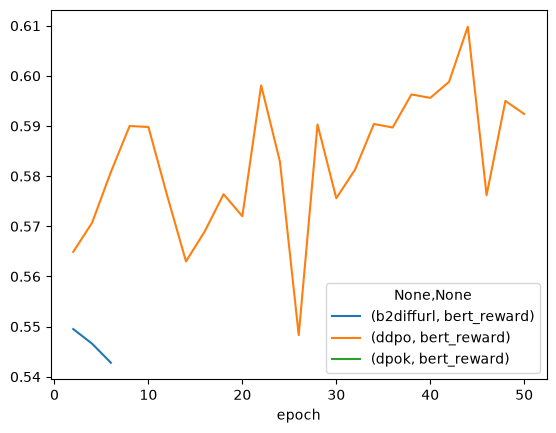

In [6]:
import matplotlib.pyplot as plt

eval_summary = eval_df.pivot_table(
    index=['method', 'score'],
    columns='epoch',
    values='value',
)
eval_summary.T.iloc[:, 0].rolling(1).mean().plot(legend=True)
eval_summary.T.iloc[:, 2].rolling(1).mean().plot(legend=True)
eval_summary.T.iloc[:, 4].rolling(1).mean().plot(legend=True)
# plt.title("Bert Reward")
# plt.show()

# plt.title("Clip Reward")
plt.show()